## **02. Modelagem Preditiva — Detecção de Fraudes em Cartão de Crédito**

**Prioridade do negócio:** Maximizar Recall — cada fraude não detectada é prejuízo direto.  
**Métrica de seleção de threshold:** F2-Score (Recall com peso 2×).

## Pipeline
```
Dados brutos
    - Feature Engineering (log Amount, sin/cos Time)
    - Divisão temporal (80/20 por Time) — sem data leakage
    - Escalonamento (RobustScaler — resistente a outliers)
    - Comparação de balanceamento (Baseline, Undersampling, SMOTE, SMOTE+Tomek)
    - Modelos: Regressão Logística, Random Forest, LightGBM
    - Tuning de threshold por F2-Score
    - Avaliação final: Recall, PR-AUC, F2-Score
    - Salvar modelo final
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing      import RobustScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    recall_score, precision_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    matthews_corrcoef
)
from imblearn.over_sampling     import SMOTE
from imblearn.under_sampling    import RandomUnderSampler
from imblearn.combine           import SMOTETomek
import lightgbm as lgb


# Caminhos 
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# Estilo 
COR_FRAUDE = '#E74C3C'
COR_LEGIT  = '#2ECC71'
COR_ACCENT = '#2980B9'
COR_RF     = '#F39C12'
COR_LGBM   = '#8E44AD'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def save_fig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')
    plt.show()
    plt.close()

## **Carregamento e Feature Engineering:**

In [2]:
df = pd.read_csv(DATA_DIR / 'creditcard.csv')
print(f'Shape: {df.shape}  |  Fraudes: {df["Class"].mean():.4%}')

# Feature Engineering
# Amount: transformação log para reduzir assimetria
df['Amount_Log'] = np.log1p(df['Amount'])

# Time: features cíclicas para capturar padrão de hora do dia
# (o dataset cobre ~48h, então Time % 86400 mapeia para hora do dia)
df['Time_Seconds_Day'] = df['Time'] % 86400
df['Time_Hour_Sin']    = np.sin(2 * np.pi * df['Time_Seconds_Day'] / 86400)
df['Time_Hour_Cos']    = np.cos(2 * np.pi * df['Time_Seconds_Day'] / 86400)

print('Features criadas: Amount_Log, Time_Hour_Sin, Time_Hour_Cos')

# Definir features
PCA_COLS     = [c for c in df.columns if c.startswith('V')]
EXTRA_COLS   = ['Amount_Log', 'Time_Hour_Sin', 'Time_Hour_Cos']
FEATURES     = PCA_COLS + EXTRA_COLS
TARGET       = 'Class'

print(f'\nTotal de features: {len(FEATURES)}')
print(f'  PCA: {len(PCA_COLS)} | Extra: {len(EXTRA_COLS)}')

Shape: (284807, 31)  |  Fraudes: 0.1727%
Features criadas: Amount_Log, Time_Hour_Sin, Time_Hour_Cos

Total de features: 31
  PCA: 28 | Extra: 3


## **Divisão Temporal (sem data leakage):**

> Em dados de fraude, a divisão aleatória pode causar data leakage. A divisão temporal é a abordagem correta para simular um cenário real de produção.

In [3]:
# Ordenar por tempo
df = df.sort_values('Time').reset_index(drop=True)

# Ponto de corte: 80% do tempo
cutoff = df['Time'].quantile(0.80)
df_train = df[df['Time'] <= cutoff].copy()
df_test  = df[df['Time']  > cutoff].copy()

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print('Divisão Temporal')
print(f'Cutoff: {cutoff/3600:.1f}h')
print(f'Treino: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%) | Fraudes: {y_train.sum()} ({y_train.mean():.4%})')
print(f'Teste:  {len(X_test):,}  ({len(X_test)/len(df)*100:.1f}%) | Fraudes: {y_test.sum()}  ({y_test.mean():.4%})')
print(f'\nSem sobreposição de índices: {len(set(X_train.index) & set(X_test.index)) == 0}')

Divisão Temporal
Cutoff: 40.3h
Treino: 227,845 (80.0%) | Fraudes: 417 (0.1830%)
Teste:  56,962  (20.0%) | Fraudes: 75  (0.1317%)

Sem sobreposição de índices: True


## **Escalonamento:**

Usamos `RobustScaler` (baseado em mediana e IQR) em vez de `StandardScaler` porque o dataset tem outliers significativos.

In [4]:
# RobustScaler: fit apenas no treino, transform em treino e teste
scaler = RobustScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURES
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES
)

# Salvar scaler para uso futuro
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f'RobustScaler salvo em models/scaler.pkl')
print(f'X_train_sc: {X_train_sc.shape} | X_test_sc: {X_test_sc.shape}')

RobustScaler salvo em models/scaler.pkl
X_train_sc: (227845, 31) | X_test_sc: (56962, 31)


## **Funções Auxiliares de Avaliação:**

In [6]:
def threshold_otimo_f2(y_true, y_proba) -> float:
    """
    Retorna o threshold que maximiza F2-Score.
    F2 penaliza falsos negativos 2× mais que falsos positivos.
    """
    prec, rec, thrs = precision_recall_curve(y_true, y_proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
    idx = np.argmax(f2[:-1])
    return float(thrs[idx])


def avaliar(y_true, y_pred, y_proba, nome: str) -> dict:
    """
    Calcula e imprime todas as métricas relevantes para detecção de fraude.
    Retorna dicionário com os valores para comparação posterior.
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rec   = recall_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred)
    f2    = fbeta_score(y_true, y_pred, beta=2)
    mcc   = matthews_corrcoef(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    print(f'\n{"─"*50}')
    print(f'  {nome}')
    print(f'{"─"*50}')
    print(f'  Recall    : {rec:.4f} (prioridade)')
    print(f'  Precisão  : {prec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  F2-Score  : {f2:.4f}')
    print(f'  MCC       : {mcc:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  PR-AUC    : {pr_auc:.4f}')
    print(f'  FN (fraudes perdidas) : {fn}')
    print(f'  FP (legítimas bloqueadas): {fp:,}')

    return dict(nome=nome, recall=rec, precision=prec,
                f1=f1, f2=f2, mcc=mcc, auc=auc, pr_auc=pr_auc,
                fn=fn, fp=fp, tp=tp, tn=tn,
                y_pred=y_pred, y_proba=y_proba)


print('Funções de avaliação definidas')

Funções de avaliação definidas


## **Comparação de Estratégias de Balanceamento:**

Regressão Logística como modelo fixo para isolar o efeito da estratégia de balanceamento.

In [7]:
def treinar_lr_com_balanceamento(X_tr, y_tr, X_te, y_te,
                                  X_tr_bal, y_tr_bal, nome: str) -> dict:
    modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
    modelo.fit(X_tr_bal, y_tr_bal)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    thr     = threshold_otimo_f2(y_te, y_proba)
    y_pred  = (y_proba >= thr).astype(int)
    res     = avaliar(y_te, y_pred, y_proba, f'{nome} (thr={thr:.3f})')
    res['threshold'] = thr
    return res

resultados_balanceamento = []

# 1. Baseline — class_weight='balanced'
print('Treinando: Baseline (class_weight)...')
m_base = LogisticRegression(max_iter=1000, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
m_base.fit(X_train_sc, y_train)
yp_base  = m_base.predict_proba(X_test_sc)[:, 1]
thr_base = threshold_otimo_f2(y_test, yp_base)
ypred_base = (yp_base >= thr_base).astype(int)
res_base = avaliar(y_test, ypred_base, yp_base, f'LR Baseline (thr={thr_base:.3f})')
res_base['threshold'] = thr_base
resultados_balanceamento.append(res_base)

# 2. Undersampling
print('\nTreinando: Undersampling...')
under = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = under.fit_resample(X_train_sc, y_train)
res_under = treinar_lr_com_balanceamento(
    X_train_sc, y_train, X_test_sc, y_test, X_under, y_under, 'LR Undersampling')
resultados_balanceamento.append(res_under)

# 3. SMOTE
print('\nTreinando: SMOTE...')
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)
res_smote = treinar_lr_com_balanceamento(
    X_train_sc, y_train, X_test_sc, y_test, X_smote, y_smote, 'LR SMOTE')
resultados_balanceamento.append(res_smote)

# 4. SMOTE + Tomek
print('\nTreinando: SMOTE+Tomek...')
smotetomek = SMOTETomek(random_state=RANDOM_STATE)
X_hybrid, y_hybrid = smotetomek.fit_resample(X_train_sc, y_train)
res_hybrid = treinar_lr_com_balanceamento(
    X_train_sc, y_train, X_test_sc, y_test, X_hybrid, y_hybrid, 'LR SMOTE+Tomek')
resultados_balanceamento.append(res_hybrid)

Treinando: Baseline (class_weight)...

──────────────────────────────────────────────────
  LR Baseline (thr=0.999)
──────────────────────────────────────────────────
  Recall    : 0.7867 (prioridade)
  Precisão  : 0.6941
  F1-Score  : 0.7375
  F2-Score  : 0.7662
  MCC       : 0.7386
  AUC-ROC   : 0.9856
  PR-AUC    : 0.7596
  FN (fraudes perdidas) : 16
  FP (legítimas bloqueadas): 26

Treinando: Undersampling...

──────────────────────────────────────────────────
  LR Undersampling (thr=1.000)
──────────────────────────────────────────────────
  Recall    : 0.7600 (prioridade)
  Precisão  : 0.6129
  F1-Score  : 0.6786
  F2-Score  : 0.7252
  MCC       : 0.6820
  AUC-ROC   : 0.9810
  PR-AUC    : 0.5448
  FN (fraudes perdidas) : 18
  FP (legítimas bloqueadas): 36

Treinando: SMOTE...

──────────────────────────────────────────────────
  LR SMOTE (thr=1.000)
──────────────────────────────────────────────────
  Recall    : 0.7867 (prioridade)
  Precisão  : 0.7195
  F1-Score  : 0.7516
  F2-

In [8]:
# Tabela comparativa
df_bal = pd.DataFrame([{
    'Abordagem' : r['nome'].split('(')[0].strip(),
    'Threshold' : round(r['threshold'], 3),
    'Recall'    : round(r['recall'], 4),
    'Precisão'  : round(r['precision'], 4),
    'F2-Score'  : round(r['f2'], 4),
    'PR-AUC'    : round(r['pr_auc'], 4),
    'FN'        : r['fn'],
    'FP'        : r['fp'],
} for r in resultados_balanceamento]).sort_values('Recall', ascending=False)

print('=== Comparação de Abordagens de Balanceamento (Regressão Logística) ===')
print(df_bal.to_string(index=False))

# Escolher melhor abordagem para modelos avançados
melhor_idx  = df_bal['F2-Score'].idxmax()
melhor_nome = df_bal.loc[melhor_idx, 'Abordagem']
print(f'\nMelhor abordagem por F2-Score: {melhor_nome}')

=== Comparação de Abordagens de Balanceamento (Regressão Logística) ===
       Abordagem  Threshold  Recall  Precisão  F2-Score  PR-AUC  FN  FP
     LR Baseline      0.999  0.7867    0.6941    0.7662  0.7596  16  26
        LR SMOTE      1.000  0.7867    0.7195    0.7723  0.7761  16  23
  LR SMOTE+Tomek      1.000  0.7867    0.7195    0.7723  0.7761  16  23
LR Undersampling      1.000  0.7600    0.6129    0.7252  0.5448  18  36

Melhor abordagem por F2-Score: LR SMOTE


Salvo: ..\figures\08_comparacao_balanceamento.png


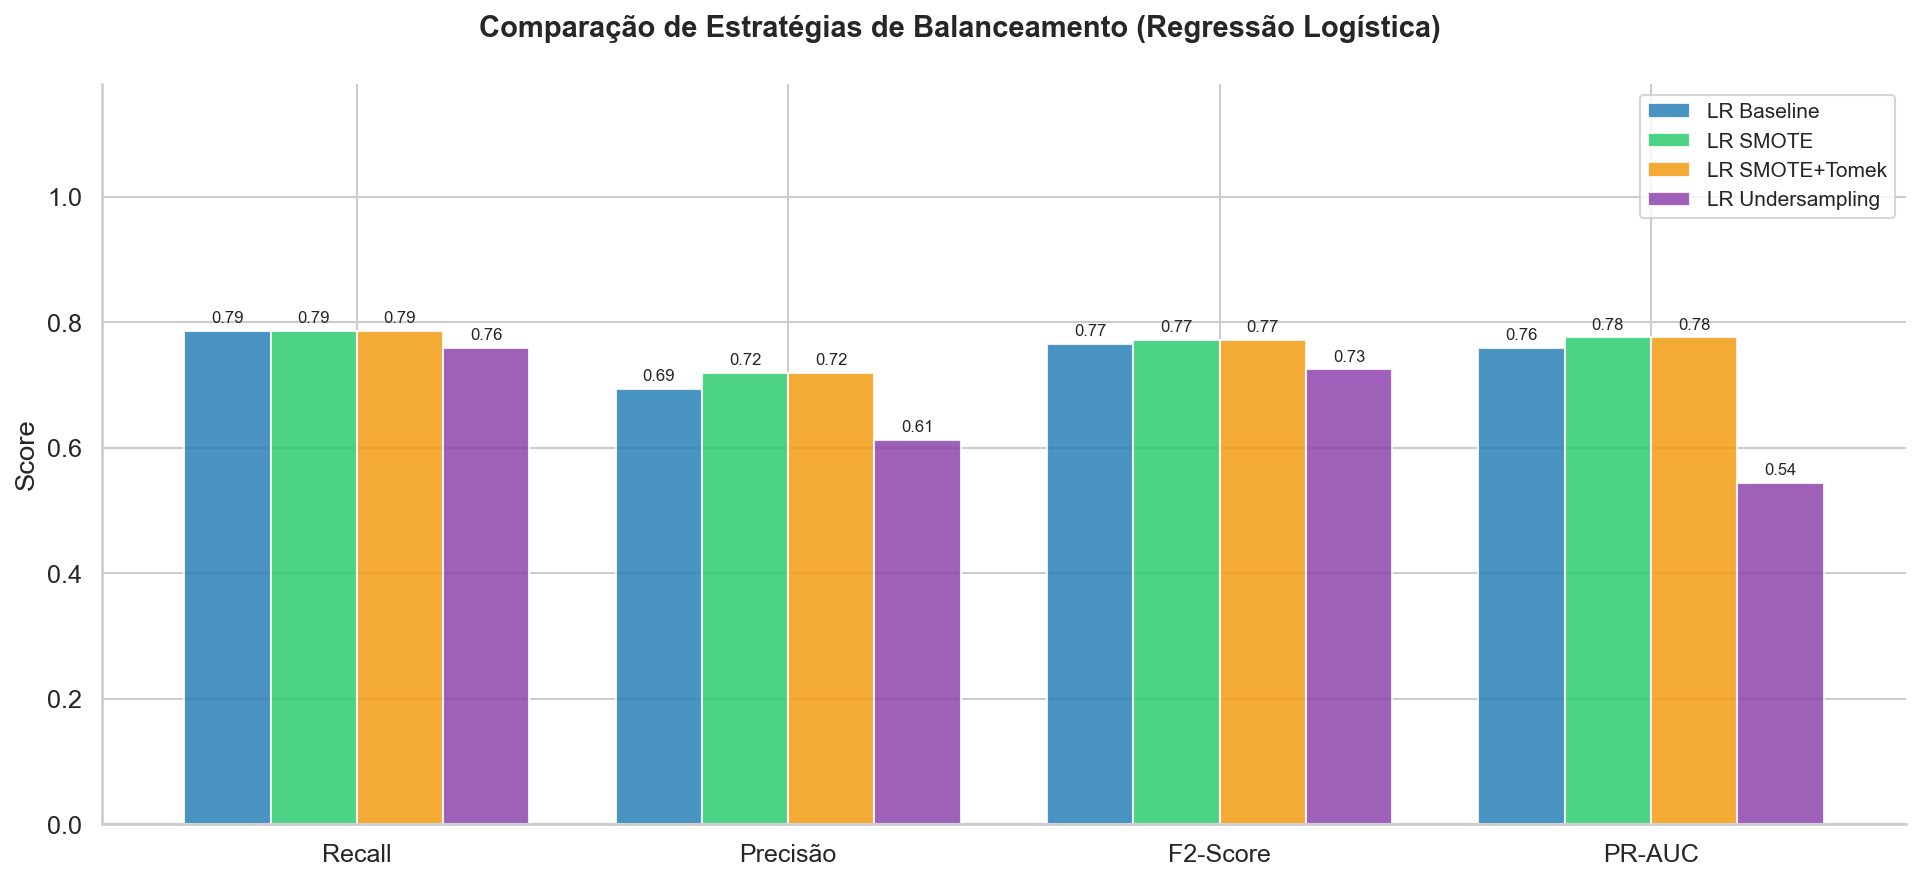

In [9]:
# Gráfico comparativo
metricas_plot = ['Recall', 'Precisão', 'F2-Score', 'PR-AUC']
abordagens    = df_bal['Abordagem'].tolist()
x = np.arange(len(metricas_plot))
w = 0.20
cores = [COR_ACCENT, COR_LEGIT, COR_RF, COR_LGBM]

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Comparação de Estratégias de Balanceamento (Regressão Logística)',
             fontsize=14, fontweight='bold')

for i, (abord, cor) in enumerate(zip(abordagens, cores)):
    vals = df_bal[df_bal['Abordagem'] == abord][metricas_plot].values[0]
    bars = ax.bar(x + i*w, vals, w, label=abord, color=cor,
                  alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_fig('08_comparacao_balanceamento')

## **Preparar Dados com Melhor Abordagem de Balanceamento:**

In [10]:
# Usar SMOTE como abordagem base para modelos avançados
print('Aplicando SMOTE para modelos avançados...')
smote_final = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote_final.fit_resample(X_train_sc, y_train)

print(f'Treino balanceado: {y_train_bal.value_counts()[0]:,} legítimas | {y_train_bal.value_counts()[1]:,} fraudes')
print(f'Proporção: {y_train_bal.mean():.1%} fraudes')

Aplicando SMOTE para modelos avançados...
Treino balanceado: 227,428 legítimas | 227,428 fraudes
Proporção: 50.0% fraudes


## **Modelos Avançados:**

In [11]:
# Regressão Logística (baseline final)
print('Treinando: Regressão Logística...')
m_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
m_lr.fit(X_train_bal, y_train_bal)
yp_lr   = m_lr.predict_proba(X_test_sc)[:, 1]
thr_lr  = threshold_otimo_f2(y_test, yp_lr)
res_lr  = avaliar(y_test, (yp_lr >= thr_lr).astype(int), yp_lr,
                  f'Regressão Logística (thr={thr_lr:.3f})')
res_lr['threshold'] = thr_lr

# Random Forest
print('\nTreinando: Random Forest...')
m_rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
m_rf.fit(X_train_bal, y_train_bal)
yp_rf   = m_rf.predict_proba(X_test_sc)[:, 1]
thr_rf  = threshold_otimo_f2(y_test, yp_rf)
res_rf  = avaliar(y_test, (yp_rf >= thr_rf).astype(int), yp_rf,
                  f'Random Forest (thr={thr_rf:.3f})')
res_rf['threshold'] = thr_rf

Treinando: Regressão Logística...

──────────────────────────────────────────────────
  Regressão Logística (thr=1.000)
──────────────────────────────────────────────────
  Recall    : 0.7867 (prioridade)
  Precisão  : 0.7195
  F1-Score  : 0.7516
  F2-Score  : 0.7723
  MCC       : 0.7520
  AUC-ROC   : 0.9844
  PR-AUC    : 0.7761
  FN (fraudes perdidas) : 16
  FP (legítimas bloqueadas): 23

Treinando: Random Forest...

──────────────────────────────────────────────────
  Random Forest (thr=0.548)
──────────────────────────────────────────────────
  Recall    : 0.7733 (prioridade)
  Precisão  : 0.8788
  F1-Score  : 0.8227
  F2-Score  : 0.7923
  MCC       : 0.8242
  AUC-ROC   : 0.9825
  PR-AUC    : 0.8107
  FN (fraudes perdidas) : 17
  FP (legítimas bloqueadas): 8


In [19]:
# LightGBM
print('Treinando: LightGBM...')
scale_pos = y_train_bal.value_counts()[0] / y_train_bal.value_counts()[1]
m_lgbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=7, num_leaves=63,
    min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE, n_jobs=-1,
    verbose=-1
)
m_lgbm.fit(X_train_bal, y_train_bal)
yp_lgbm  = m_lgbm.predict_proba(X_test_sc)[:, 1]
thr_lgbm = threshold_otimo_f2(y_test, yp_lgbm)
res_lgbm = avaliar(y_test, (yp_lgbm >= thr_lgbm).astype(int), yp_lgbm,
                   f'LightGBM (thr={thr_lgbm:.3f})')
res_lgbm['threshold'] = thr_lgbm
todos_resultados = [res_lr, res_rf, res_lgbm]

Treinando: LightGBM...

──────────────────────────────────────────────────
  LightGBM (thr=0.969)
──────────────────────────────────────────────────
  Recall    : 0.7467 (prioridade)
  Precisão  : 0.9492
  F1-Score  : 0.8358
  F2-Score  : 0.7799
  MCC       : 0.8417
  AUC-ROC   : 0.9758
  PR-AUC    : 0.7772
  FN (fraudes perdidas) : 19
  FP (legítimas bloqueadas): 3


## **Tabela Comparativa Final:**

In [20]:
df_res = pd.DataFrame([{
    'Modelo'    : r['nome'].split('(')[0].strip(),
    'Threshold' : round(r['threshold'], 3),
    'Recall'    : round(r['recall'], 4),
    'Precisão'  : round(r['precision'], 4),
    'F1-Score'  : round(r['f1'], 4),
    'F2-Score'  : round(r['f2'], 4),
    'MCC'       : round(r['mcc'], 4),
    'AUC-ROC'   : round(r['auc'], 4),
    'PR-AUC'    : round(r['pr_auc'], 4),
    'FN'        : r['fn'],
    'FP'        : r['fp'],
} for r in todos_resultados]).sort_values('F2-Score', ascending=False)

print('Comparação Final dos Modelos')
print(df_res.to_string(index=False))

df_res.to_csv(MODELS_DIR / 'resultados_modelos.csv', index=False)
print('\nResultados salvos em models/resultados_modelos.csv')

=== Comparação Final dos Modelos ===
             Modelo  Threshold  Recall  Precisão  F1-Score  F2-Score    MCC  AUC-ROC  PR-AUC  FN  FP
      Random Forest      0.548  0.7733    0.8788    0.8227    0.7923 0.8242   0.9825  0.8107  17   8
           LightGBM      0.969  0.7467    0.9492    0.8358    0.7799 0.8417   0.9758  0.7772  19   3
Regressão Logística      1.000  0.7867    0.7195    0.7516    0.7723 0.7520   0.9844  0.7761  16  23

Resultados salvos em models/resultados_modelos.csv


## **Curvas Precision-Recall e ROC:**

Salvo: ..\figures\09_curvas_pr_roc.png


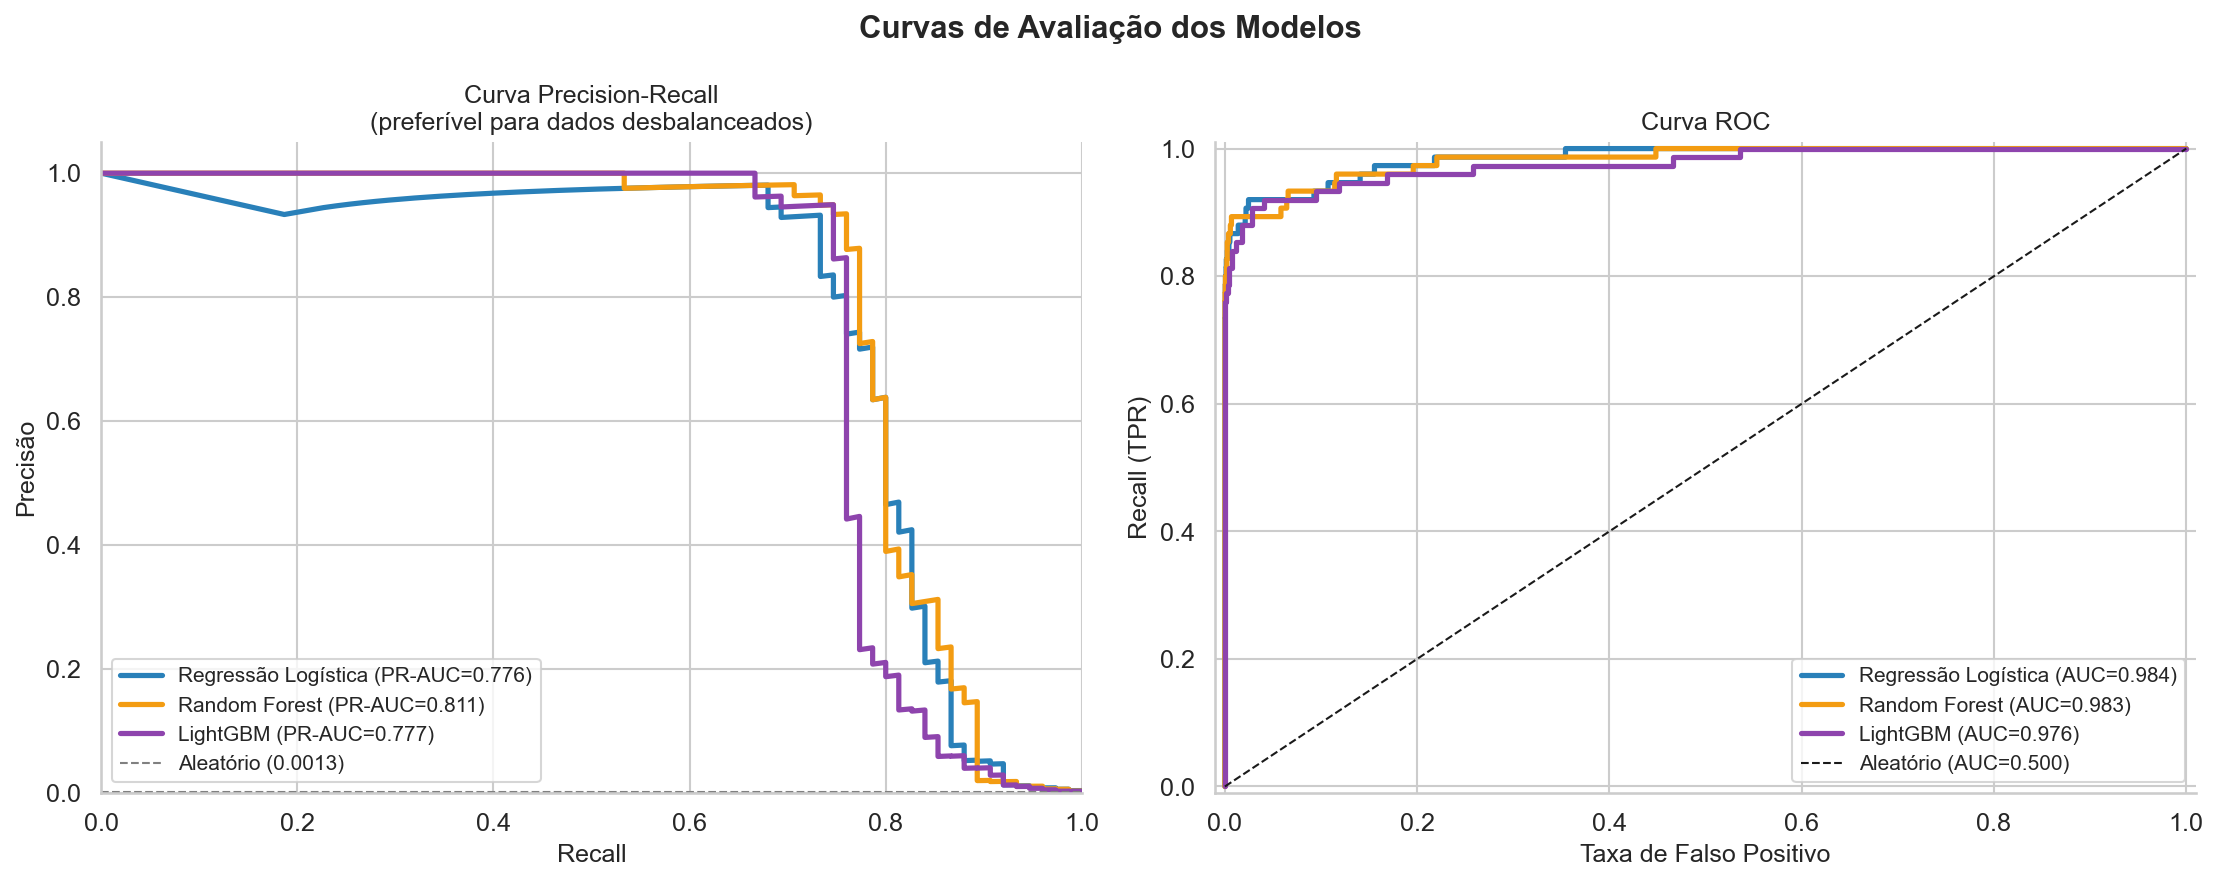

In [21]:
cores_modelos = [COR_ACCENT, COR_RF]
cores_modelos.append(COR_LGBM)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Curvas de Avaliação dos Modelos', fontsize=15, fontweight='bold')

# Precision-Recall (mais informativa para dados desbalanceados)
ax = axes[0]
for res, cor in zip(todos_resultados, cores_modelos):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    pr_auc = res['pr_auc']
    nome   = res['nome'].split('(')[0].strip()
    ax.plot(rec, prec, color=cor, linewidth=2.5,
            label=f'{nome} (PR-AUC={pr_auc:.3f})')
# Linha de referência (classificador aleatório)
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='gray', linestyle='--', linewidth=1,
           label=f'Aleatório ({baseline_pr:.4f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisão', fontsize=12)
ax.set_title('Curva Precision-Recall\n(preferível para dados desbalanceados)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# ROC
ax = axes[1]
for res, cor in zip(todos_resultados, cores_modelos):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc  = res['auc']
    nome = res['nome'].split('(')[0].strip()
    ax.plot(fpr, tpr, color=cor, linewidth=2.5,
            label=f'{nome} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Aleatório (AUC=0.500)')
ax.set_xlabel('Taxa de Falso Positivo', fontsize=12)
ax.set_ylabel('Recall (TPR)', fontsize=12)
ax.set_title('Curva ROC', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
save_fig('09_curvas_pr_roc')

## **Matrizes de Confusão:**

Salvo: ..\figures\10_matrizes_confusao.png


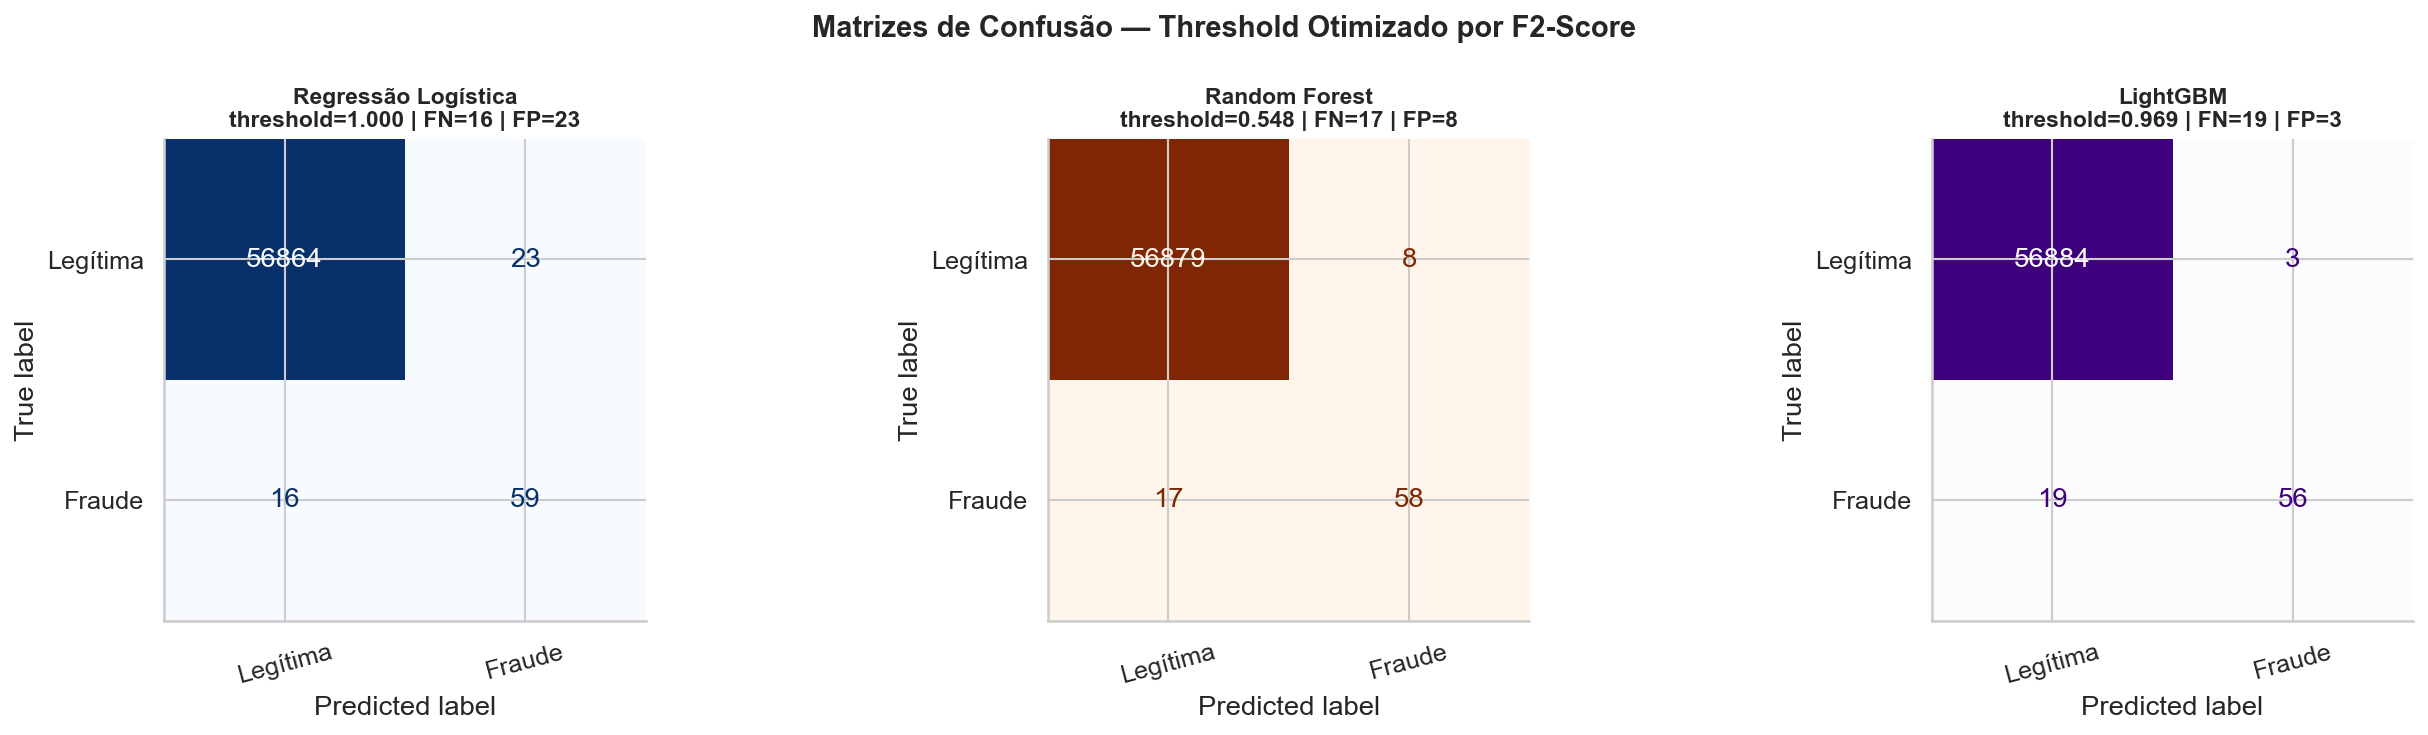

In [22]:
n_modelos = len(todos_resultados)
fig, axes = plt.subplots(1, n_modelos, figsize=(6*n_modelos, 5))
if n_modelos == 1:
    axes = [axes]
fig.suptitle('Matrizes de Confusão — Threshold Otimizado por F2-Score',
             fontsize=14, fontweight='bold')

cmaps = ['Blues', 'Oranges', 'Purples']
for ax, res, cmap in zip(axes, todos_resultados, cmaps):
    cm   = confusion_matrix(y_test, res['y_pred'])
    nome = res['nome'].split('(')[0].strip()
    thr  = res['threshold']
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima','Fraude'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')
    ax.set_title(f'{nome}\nthreshold={thr:.3f} | FN={res["fn"]} | FP={res["fp"]:,}',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('10_matrizes_confusao')

## **Feature Importance:**

Salvo: ..\figures\11_feature_importance.png


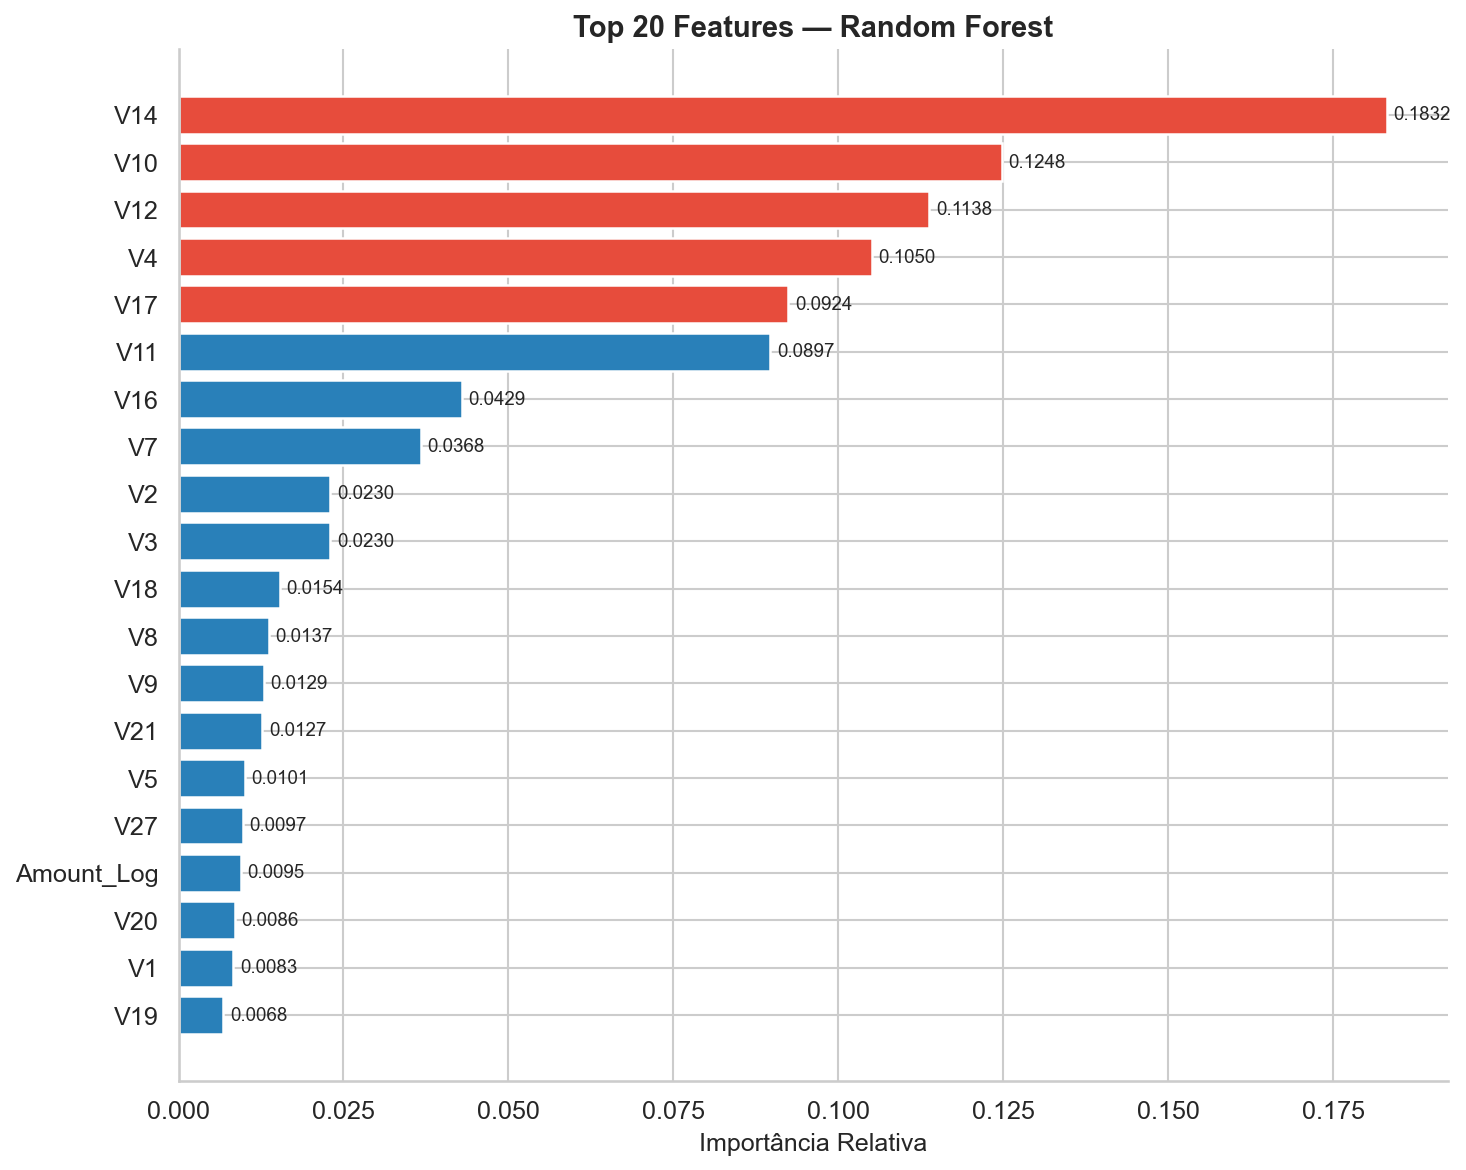

In [23]:
# Usar Random Forest para feature importance
fi = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': m_rf.feature_importances_,
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Top 20 Features — Random Forest', fontsize=14, fontweight='bold')

cores_fi = [COR_FRAUDE if v >= fi['Importance'].quantile(0.75) else COR_ACCENT
            for v in fi['Importance']]
bars = ax.barh(fi['Feature'], fi['Importance'],
               color=cores_fi, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, fi['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importância Relativa', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
save_fig('11_feature_importance')

## **Salvar Modelo Final:**

In [25]:
# Selecionar modelo com maior F2-Score
melhor_res   = max(todos_resultados, key=lambda r: r['f2'])
melhor_nome  = melhor_res['nome'].split('(')[0].strip()
melhor_model = {'Regressão Logística': m_lr,
                'Random Forest'      : m_rf}.get(
    melhor_nome,
    m_lgbm 
)

joblib.dump(melhor_model,           MODELS_DIR / 'modelo_final.pkl')
joblib.dump(melhor_res['threshold'], MODELS_DIR / 'threshold_final.pkl')
joblib.dump(FEATURES,               MODELS_DIR / 'features.pkl')

print(f'Modelo salvo: {melhor_nome}')
print(f'   Threshold  : {melhor_res["threshold"]:.4f}')
print(f'   Recall     : {melhor_res["recall"]:.4f}')
print(f'   F2-Score   : {melhor_res["f2"]:.4f}')
print(f'   PR-AUC     : {melhor_res["pr_auc"]:.4f}')
print(f'   FN         : {melhor_res["fn"]} fraudes não detectadas')
print(f'   FP         : {melhor_res["fp"]:,} legítimas bloqueadas')

Modelo salvo: Random Forest
   Threshold  : 0.5475
   Recall     : 0.7733
   F2-Score   : 0.7923
   PR-AUC     : 0.8107
   FN         : 17 fraudes não detectadas
   FP         : 8 legítimas bloqueadas
